# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/aamr8010/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [1]:
import pandas as pd
import numpy as np
import os

from google.colab import userdata
from datasets import load_dataset


HF_TOKEN = userdata.get("HF_TOKEN")

if not HF_TOKEN:
    raise ValueError(
        "HF_TOKEN not found. Go to Colab -> Secrets -> "
        "make sure HF_TOKEN exists and is enabled."
    )

print("HF token loaded:", bool(HF_TOKEN))

ds = load_dataset(
    "FlyRank/internship-warehouse",
    "fact_content_daily_performance",
    split="train",
    streaming=True,
    token=HF_TOKEN
)



rows = []

for row in ds:
    rows.append(row)

    if len(rows) == 30000:
        break


df = pd.DataFrame(rows)



print("Dataset loaded successfully.")
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

HF token loaded: True


README.md:   0%|          | 0.00/3.04k [00:00<?, ?B/s]

Resolving data files:   0%|          | 0/18 [00:00<?, ?it/s]

Dataset loaded successfully.
Shape: (30000, 30)

Columns:
['report_date', 'client_hash_id', 'content_hash_id', 'client_has_gsc', 'client_has_ga4', 'gsc_data_available', 'ga4_data_available', 'gsc_impressions', 'gsc_clicks', 'gsc_sum_position', 'gsc_avg_position', 'ga4_pageviews', 'ga4_sessions', 'ga4_users', 'ga4_engaged_sessions', 'ga4_total_engagement_sec', 'sessions_organic', 'sessions_direct', 'sessions_referral', 'sessions_social', 'sessions_paid', 'sessions_ai', 'ai_chatgpt', 'ai_perplexity', 'ai_gemini', 'ai_copilot', 'ai_claude', 'ai_meta', 'ai_other', 'scroll_events']


In [2]:

# Data validation

df["report_date"] = pd.to_datetime(
    df["report_date"],
    errors="coerce"
)

print("Dataset shape:", df.shape)

print("\nDate range:")
print("Min:", df["report_date"].min())
print("Max:", df["report_date"].max())

print("\nUnique clients:")
print(df["client_hash_id"].nunique())

print("\nUnique content:")
print(df["content_hash_id"].nunique())

print("\nMissing values:")
print(df.isna().sum().sort_values(ascending=False).head(15))

Dataset shape: (30000, 30)

Date range:
Min: 2025-01-27 00:00:00
Max: 2025-02-22 00:00:00

Unique clients:
3

Unique content:
5673

Missing values:
gsc_avg_position        1
gsc_sum_position        1
content_hash_id         0
client_has_gsc          0
report_date             0
client_hash_id          0
gsc_data_available      0
client_has_ga4          0
gsc_impressions         0
ga4_data_available      0
gsc_clicks              0
ga4_pageviews           0
ga4_sessions            0
ga4_users               0
ga4_engaged_sessions    0
dtype: int64


# ML-08 — Capstone Modeling Lane

## Research Question

Which observable search and engagement signals are most useful for identifying content that should receive human review and optimization attention?

## Lane

Refresh / Content Opportunity Scoring

## Decision Supported

The analysis is intended to help content teams prioritize pages for human review based on observed search visibility, clicks, engagement, and traffic signals.

The output is decision-support rather than an automated publishing or ranking system.

## Unit of Analysis

The primary unit of analysis is content observed on a reporting date.

## Public-Safe Framing

The analysis uses pseudonymous identifiers only for grouping and aggregation. No client-identifying information, domains, private queries, or credentials are exposed.

In [3]:

# Feature engineering


work = df.copy()

# Avoid division-by-zero
work["ctr"] = np.where(
    work["gsc_impressions"] > 0,
    work["gsc_clicks"] / work["gsc_impressions"],
    np.nan
)

work["engagement_rate"] = np.where(
    work["ga4_sessions"] > 0,
    work["ga4_engaged_sessions"] / work["ga4_sessions"],
    np.nan
)

work["organic_share"] = np.where(
    work["ga4_sessions"] > 0,
    work["sessions_organic"] / work["ga4_sessions"],
    np.nan
)

work["ai_share"] = np.where(
    work["ga4_sessions"] > 0,
    work["sessions_ai"] / work["ga4_sessions"],
    np.nan
)

work["clicks_per_session"] = np.where(
    work["ga4_sessions"] > 0,
    work["gsc_clicks"] / work["ga4_sessions"],
    np.nan
)

print("Engineered features:")
print([
    "ctr",
    "engagement_rate",
    "organic_share",
    "ai_share",
    "clicks_per_session"
])

Engineered features:
['ctr', 'engagement_rate', 'organic_share', 'ai_share', 'clicks_per_session']


In [4]:

# Transparent opportunity scoring


score_df = work.copy()

# Rank percentile for each signal
score_df["impression_rank"] = (
    score_df["gsc_impressions"]
    .rank(pct=True)
    .fillna(0)
)

score_df["click_rank"] = (
    score_df["gsc_clicks"]
    .rank(pct=True)
    .fillna(0)
)

score_df["session_rank"] = (
    score_df["ga4_sessions"]
    .rank(pct=True)
    .fillna(0)
)

score_df["engagement_rank"] = (
    score_df["engagement_rate"]
    .rank(pct=True)
    .fillna(0)
)

# Opportunity score:
# visibility + clicks + traffic + engagement
score_df["opportunity_score"] = (
    0.30 * score_df["impression_rank"]
    + 0.30 * score_df["click_rank"]
    + 0.20 * score_df["session_rank"]
    + 0.20 * score_df["engagement_rank"]
)

print(
    score_df[
        [
            "content_hash_id",
            "report_date",
            "opportunity_score"
        ]
    ]
    .head()
)

            content_hash_id report_date  opportunity_score
0  content_3b70a18ea133b2bb  2025-01-27           0.505998
1  content_fe8e8155ce1d47a2  2025-01-27           0.363568
2  content_b4462a1b90640058  2025-01-27           0.260983
3  content_c899aef92518c714  2025-01-27           0.379163
4  content_c7c1d2e68d9d0964  2025-01-27           0.363568


In [5]:

# Reason codes

def get_reason(row):

    reasons = []

    if row["gsc_impressions"] > score_df["gsc_impressions"].quantile(0.75):
        reasons.append("high_visibility")

    if row["gsc_clicks"] > score_df["gsc_clicks"].quantile(0.75):
        reasons.append("high_click_volume")

    if pd.notna(row["engagement_rate"]) and \
       row["engagement_rate"] > score_df["engagement_rate"].median():
        reasons.append("healthy_engagement")

    if pd.notna(row["organic_share"]) and \
       row["organic_share"] > score_df["organic_share"].median():
        reasons.append("strong_organic_share")

    if not reasons:
        reasons.append("monitor")

    return ", ".join(reasons)


score_df["reason_code"] = score_df.apply(
    get_reason,
    axis=1
)

print(
    score_df[
        [
            "content_hash_id",
            "opportunity_score",
            "reason_code"
        ]
    ].head(10)
)

            content_hash_id  opportunity_score      reason_code
0  content_3b70a18ea133b2bb           0.505998  high_visibility
1  content_fe8e8155ce1d47a2           0.363568          monitor
2  content_b4462a1b90640058           0.260983          monitor
3  content_c899aef92518c714           0.379163          monitor
4  content_c7c1d2e68d9d0964           0.363568          monitor
5  content_c782fa8abd4fce5e           0.483163  high_visibility
6  content_ae5e5fd6edff550f           0.445808          monitor
7  content_a64143f6e4a21ffe           0.504133  high_visibility
8  content_e281674658070602           0.363568          monitor
9  content_658f53fa439c66ca           0.403793          monitor


In [6]:

# Ranked action queue


queue = (
    score_df[
        [
            "content_hash_id",
            "report_date",
            "opportunity_score",
            "reason_code",
            "gsc_impressions",
            "gsc_clicks",
            "gsc_avg_position",
            "ga4_sessions",
            "engagement_rate"
        ]
    ]
    .sort_values(
        "opportunity_score",
        ascending=False
    )
    .reset_index(drop=True)
)

queue["rank"] = np.arange(1, len(queue) + 1)

queue["recommended_action"] = np.where(
    queue["opportunity_score"] >= queue["opportunity_score"].quantile(0.80),
    "human_review",
    "monitor"
)

print("Top 20 recommendations:")
display(queue.head(20))

Top 20 recommendations:


,content_hash_id,report_date,opportunity_score,reason_code,gsc_impressions,gsc_clicks,gsc_avg_position,ga4_sessions,engagement_rate,rank,recommended_action
0,content_690b092cf66bc2a4,2025-02-22,0.699983,"high_visibility, high_click_volume",534,15,1.750936,0,NaN,1,human_review
1,content_690b092cf66bc2a4,2025-02-20,0.699938,"high_visibility, high_click_volume",532,11,1.832707,0,NaN,2,human_review
2,content_4e8d1e11f60fe6ba,2025-02-12,0.699928,"high_visibility, high_click_volume",506,11,7.045455,0,NaN,3,human_review
3,content_a64143f6e4a21ffe,2025-02-21,0.699923,"high_visibility, high_click_volume",580,8,4.984483,0,NaN,4,human_review
4,content_a64143f6e4a21ffe,2025-02-22,0.699913,"high_visibility, high_click_volume",458,12,3.578603,0,NaN,5,human_review
5,content_690b092cf66bc2a4,2025-02-21,0.699908,"high_visibility, high_click_volume",493,11,1.766734,0,NaN,6,human_review
6,content_ce78d1eaabd3fc7a,2025-02-22,0.699798,"high_visibility, high_click_volume",358,11,5.955307,0,NaN,7,human_review
7,content_06de5368fbd3bf99,2025-02-20,0.699753,"high_visibility, high_click_volume",535,5,23.874766,0,NaN,8,human_review
8,content_f94fe855380e150f,2025-02-01,0.699718,"high_visibility, high_click_volume",353,7,1.671388,0,NaN,9,human_review
9,content_ce78d1eaabd3fc7a,2025-02-20,0.699673,"high_visibility, high_click_volume",441,5,5.916100,0,NaN,10,human_review


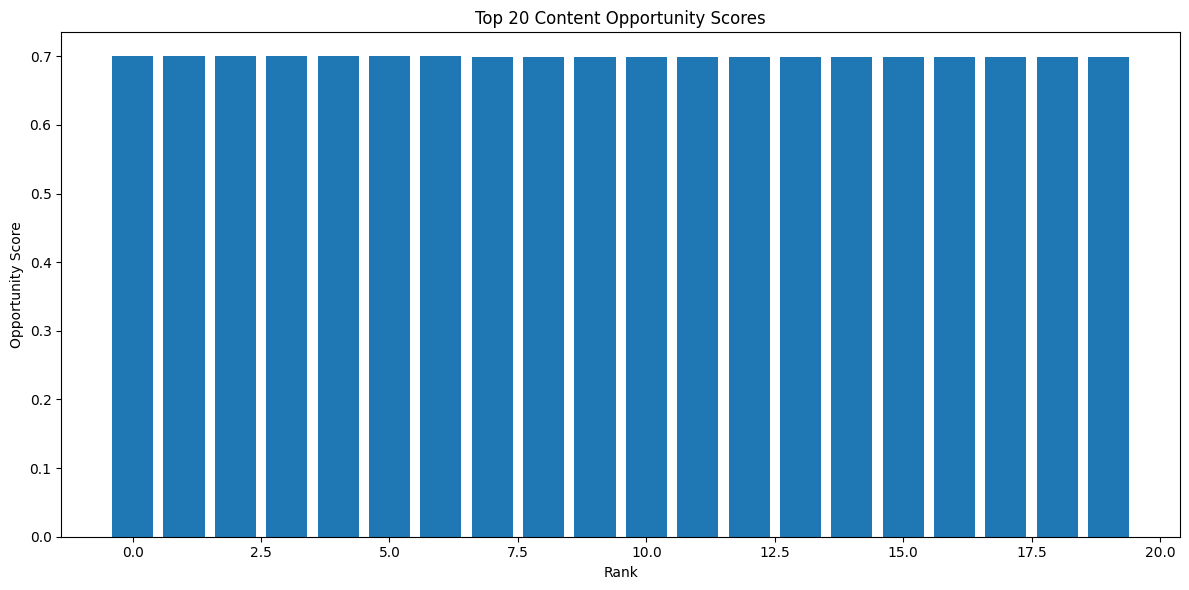

In [7]:
import matplotlib.pyplot as plt

top20 = queue.head(20).copy()

plt.figure(figsize=(12, 6))

plt.bar(
    range(len(top20)),
    top20["opportunity_score"]
)

plt.xlabel("Rank")
plt.ylabel("Opportunity Score")
plt.title("Top 20 Content Opportunity Scores")

plt.tight_layout()

plt.savefig(
    "top20_opportunity_scores.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

## Interpretation

The ranked output identifies content records with relatively strong observed visibility, click, traffic, and engagement signals.

The score is intentionally transparent and should be interpreted as a prioritization mechanism rather than a prediction of future search performance.

High-ranked records are candidates for human review. The ranking does not establish that changing a page will cause higher Google rankings, clicks, or traffic.

The main value of the output is prioritization: it reduces a large set of content observations into a smaller review queue using measurable signals.

## Limitations

This analysis has several important limitations.

1. The current extract does not provide an explicit future-outcome label.
2. The opportunity score is a transparent ranking rule rather than a supervised predictive model.
3. The score describes observed signals and does not establish causality.
4. Pseudonymous content identifiers cannot be interpreted as real URLs or client identities.
5. The output should be reviewed by a human before any content change is made.
6. The analysis should not be interpreted as predicting Google's ranking algorithm.
7. The available extract covers a limited reporting window, so long-term seasonality and future performance are not evaluated.

## Ranked Recommendations

### 1. Human-review high-ranked content

Review the highest-ranked records first because they combine relatively strong observed visibility, clicks, traffic, and engagement signals.

### 2. Review pages with strong visibility but weaker click capture

Where impressions are high but clicks are comparatively weaker, review titles, descriptions, search intent alignment, and content positioning.

### 3. Protect strong-performing content

Records showing strong clicks and engagement should be monitored before making substantial changes.

### 4. Monitor lower-confidence records

Records without strong supporting signals should remain in monitoring rather than receiving immediate content changes.

## Human Review Rule

No content should be automatically rewritten, deleted, merged, or published based solely on this score.

The score is decision-support and requires editorial review.

In [8]:

# Export artifacts


os.makedirs("work/outputs", exist_ok=True)
os.makedirs("work/figures", exist_ok=True)

queue.to_csv(
    "work/outputs/ranked_action_queue.csv",
    index=False
)

# Move/copy figure
import shutil

if os.path.exists("top20_opportunity_scores.png"):
    shutil.copy(
        "top20_opportunity_scores.png",
        "work/figures/top20_opportunity_scores.png"
    )

print("Exports created:")
print("work/outputs/ranked_action_queue.csv")
print("work/figures/top20_opportunity_scores.png")

Exports created:
work/outputs/ranked_action_queue.csv
work/figures/top20_opportunity_scores.png


## 1. Question

*The research question and the decision it supports.*

## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

## 5. Limitations

*What this work cannot claim.*

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
